# Notebook 06 - Comparacion de Modelos

## Objetivos
- Contrastar arquitecturas BERT, GPT, T5, Llama, Mistral y DeepSeek.
- Organizar metadatos en tabla pandas.
- Relacionar tipo de modelo con casos de uso.

## Introduccion
No es necesario cargar todos los modelos: usaremos metadatos publicos para comparar paradigmas encoder, decoder y encoder-decoder.

In [1]:
from IPython.display import display
import pandas as pd

print('Tabla comparativa basada en metadatos (sin descarga de pesos)')

Tabla comparativa basada en metadatos (sin descarga de pesos)


## 1) Tabla comparativa principal

In [2]:
modelos = pd.DataFrame([
    {'modelo': 'BERT', 'tipo': 'Encoder-only', 'pretraining': 'MLM + NSP', 'fortaleza': 'Comprension', 'ejemplo_uso': 'Clasificacion, NER, QA extractivo'},
    {'modelo': 'GPT-2/3/4', 'tipo': 'Decoder-only', 'pretraining': 'CLM autoregresivo', 'fortaleza': 'Generacion', 'ejemplo_uso': 'Chatbots, redaccion, codigo'},
    {'modelo': 'T5', 'tipo': 'Encoder-Decoder', 'pretraining': 'Span corruption', 'fortaleza': 'Text-to-text', 'ejemplo_uso': 'Traduccion, resumen, QA generativo'},
    {'modelo': 'Llama', 'tipo': 'Decoder-only', 'pretraining': 'CLM a escala', 'fortaleza': 'Razonamiento general', 'ejemplo_uso': 'Asistentes open-weight'},
    {'modelo': 'Mistral', 'tipo': 'Decoder-only', 'pretraining': 'CLM eficiente', 'fortaleza': 'Costo/latencia', 'ejemplo_uso': 'Despliegue empresarial'},
    {'modelo': 'DeepSeek', 'tipo': 'Decoder-only', 'pretraining': 'CLM + RL/DPO', 'fortaleza': 'Codigo y razonamiento', 'ejemplo_uso': 'Copilotos tecnicos'},
])
display(modelos)

,modelo,tipo,pretraining,fortaleza,ejemplo_uso
0,BERT,Encoder-only,MLM + NSP,Comprension,"Clasificacion, NER, QA extractivo"
1,GPT-2/3/4,Decoder-only,CLM autoregresivo,Generacion,"Chatbots, redaccion, codigo"
2,T5,Encoder-Decoder,Span corruption,Text-to-text,"Traduccion, resumen, QA generativo"
3,Llama,Decoder-only,CLM a escala,Razonamiento general,Asistentes open-weight
4,Mistral,Decoder-only,CLM eficiente,Costo/latencia,Despliegue empresarial
5,DeepSeek,Decoder-only,CLM + RL/DPO,Codigo y razonamiento,Copilotos tecnicos


## 2) Parametros y contexto (aproximados)

In [ ]:
escala = pd.DataFrame([
    {'modelo': 'BERT-base', 'parametros': '110M', 'contexto': '512', 'open_weights': 'Si'},
    {'modelo': 'GPT-2', 'parametros': '124M-1.5B', 'contexto': '1024', 'open_weights': 'Si'},
    {'modelo': 'T5-base', 'parametros': '220M', 'contexto': '512', 'open_weights': 'Si'},
    {'modelo': 'Llama 3', 'parametros': '8B-70B', 'contexto': '8192+', 'open_weights': 'Parcial'},
    {'modelo': 'Mistral 7B', 'parametros': '7B', 'contexto': '8192+', 'open_weights': 'Si'},
    {'modelo': 'DeepSeek Coder', 'parametros': '1.3B-33B', 'contexto': '4096+', 'open_weights': 'Si'},
])
display(escala)

,modelo,parametros,contexto,open_weights
0,BERT-base,110M,512,Si
1,GPT-2,124M-1.5B,1024,Si
2,T5-base,220M,512,Si
3,Llama 3,8B-70B,8192+,Parcial
4,Mistral 7B,7B,8192+,Si
5,DeepSeek Coder,1.3B-33B,4096+,Si


## 3) Matriz modelo vs tarea

In [4]:
tareas = ['Clasificacion', 'NER', 'QA extractivo', 'Generacion libre', 'Traduccion', 'Codigo']
matriz = pd.DataFrame({
    'BERT': ['Alta', 'Alta', 'Alta', 'Baja', 'Media', 'Baja'],
    'GPT': ['Media', 'Media', 'Media', 'Alta', 'Media', 'Alta'],
    'T5': ['Alta', 'Alta', 'Alta', 'Alta', 'Alta', 'Media'],
    'Llama/Mistral/DeepSeek': ['Media', 'Media', 'Media', 'Alta', 'Alta', 'Alta'],
}, index=tareas)
display(matriz)

,BERT,GPT,T5,Llama/Mistral/DeepSeek
Clasificacion,Alta,Media,Alta,Media
NER,Alta,Media,Alta,Media
QA extractivo,Alta,Media,Alta,Media
Generacion libre,Baja,Alta,Alta,Alta
Traduccion,Media,Media,Alta,Alta
Codigo,Baja,Alta,Media,Alta


## 4) Visualizacion rapida

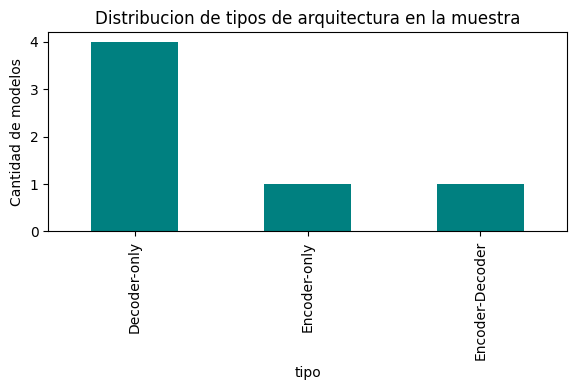

In [5]:
import matplotlib.pyplot as plt

conteo_tipo = modelos['tipo'].value_counts()
plt.figure(figsize=(6, 4))
conteo_tipo.plot(kind='bar', color='teal')
plt.title('Distribucion de tipos de arquitectura en la muestra')
plt.ylabel('Cantidad de modelos')
plt.tight_layout()
plt.show()

## Resultados
Construimos tablas comparativas de arquitectura, escala y adecuacion por tarea sin cargar checkpoints pesados.

## Conclusiones
No existe un modelo universal: encoder-only entiende, decoder-only genera, encoder-decoder unifica tareas texto-a-texto. La eleccion depende de latencia, costo y gobernanza de datos.

## Ejercicios guiados resueltos
**Ejercicio:** Filtra modelos decoder-only.

**Solucion:**

In [6]:
decoder_only = modelos[modelos['tipo'] == 'Decoder-only']
display(decoder_only[['modelo', 'fortaleza', 'ejemplo_uso']])

,modelo,fortaleza,ejemplo_uso
1,GPT-2/3/4,Generacion,"Chatbots, redaccion, codigo"
3,Llama,Razonamiento general,Asistentes open-weight
4,Mistral,Costo/latencia,Despliegue empresarial
5,DeepSeek,Codigo y razonamiento,Copilotos tecnicos


## Ejercicios propuestos
1. Agrega columnas de licencia y fecha de lanzamiento.
2. Investiga que es MoE y donde aparece (Mixtral).
3. Propón stack hibrido BERT+GPT para un chatbot empresarial.

## Preguntas de reflexion
1. Por que los LLMs decoder dominan interfaces conversacionales?
2. Cuando T5 sigue siendo preferible?
3. Que implica `open_weights: Parcial` para una empresa regulada?